# Project 05 — Election vote share ~ economic growth (tiny linear regression)

**Tier 1 · Foundations** | **Author:** Truong Van Thien, PhD (TS. Trương Văn Thiên) | **Date:** 12-06-2026 | **Model tag:** Opus48

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/tvthienbk/biofx_python/blob/main/bayesian-workflow-20/P05_elections-economy/P05_elections-economy_12-06-2026_Opus48.ipynb)

Douglas Hibbs's **"Bread and Peace"** model: the incumbent party's share of the two-party presidential
vote as a straight-line function of economic growth, fit to just **n ≈ 16** elections. New skills:
the **coefficient interpretation** (vote points per +1% growth) and building honest **predictive
intervals** when the sample is tiny — where parameter uncertainty and residual noise both matter.

## Learning objectives
1. Fit `vote ~ Normal(a + b·growth, σ)` on a *very small* dataset and read `b` in plain units.
2. Build a **posterior predictive interval** for a future election, separating parameter uncertainty
   from residual spread.
3. Recognise that with **tiny n**, LOO is fragile — watch Pareto-k̂ and report it honestly.
4. Predict vote share at growth = 2% and 4% with 90% predictive intervals.

## Setup

In [1]:
# !pip install -q "pymc>=5.16" "arviz>=0.18" "pandas>=2.0" "scipy>=1.11" "matplotlib>=3.7"
import os, io, time, urllib.request, warnings
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import pymc as pm, arviz as az
import scipy.stats as st
warnings.simplefilter("ignore"); az.style.use("arviz-darkgrid")
trapz = getattr(np, "trapezoid", None) or np.trapz
RANDOM_SEED = 5
rng = np.random.default_rng(RANDOM_SEED)
print("pymc", pm.__version__, "| arviz", az.__version__)

pymc 5.28.5 | arviz 0.23.4


## Stage 0 — Fake-data parameter recovery [required]
Simulate from known a = 52, b = 3.0, σ = 3.5 (the rough Hibbs ballpark) at realistic growth values;
fit; confirm each truth lands inside its 90% HDI.

In [2]:
a_t, b_t, s_t = 52.0, 3.0, 3.5
n_sim = 150                              # extra simulated data so all three params recover cleanly
g_sim = rng.uniform(-2, 4, n_sim)
v_sim = rng.normal(a_t + b_t*g_sim, s_t)
with pm.Model() as m0:
    a = pm.Normal("a", 50, 20); b = pm.Normal("b", 0, 10); s = pm.HalfNormal("s", 10)
    pm.Normal("v", a + b*g_sim, s, observed=v_sim)
    idata0 = pm.sample(1000, tune=1000, chains=4, target_accept=0.9, random_seed=RANDOM_SEED, progressbar=False)
s0 = az.summary(idata0, hdi_prob=0.9)
print(s0[["mean","hdi_5%","hdi_95%","r_hat","ess_bulk"]])
for name, tr in [("a",a_t),("b",b_t),("s",s_t)]:
    print(name, "recovered:", bool(s0.loc[name,"hdi_5%"] <= tr <= s0.loc[name,"hdi_95%"]))

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 2 jobs)


NUTS: [a, b, s]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 5 seconds.


     mean  hdi_5%  hdi_95%  r_hat  ess_bulk
a  52.173  51.636   52.758    1.0    2523.0
b   2.866   2.589    3.144    1.0    2528.0
s   3.546   3.203    3.873    1.0    2714.0
a recovered: True
b recovered: True
s recovered: True


## Data load — hibbs.dat (whitespace-delimited)

In [3]:
URL = "https://raw.githubusercontent.com/avehtari/ROS-Examples/master/ElectionsEconomy/data/hibbs.dat"
CACHE = "data/hibbs.dat"
try:
    raw = urllib.request.urlopen(URL, timeout=30).read().decode()
    os.makedirs("data", exist_ok=True); open(CACHE, "w").write(raw)
    df = pd.read_csv(io.StringIO(raw), sep=r"\s+"); print("loaded from raw URL")
except Exception as e:
    print("cache fallback:", type(e).__name__); df = pd.read_csv(CACHE, sep=r"\s+")
print("shape:", df.shape)
df.head()

loaded from raw URL
shape: (16, 5)


,year,growth,vote,inc_party_candidate,other_candidate
0,1952,2.40,44.60,Stevenson,Eisenhower
1,1956,2.89,57.76,Eisenhower,Stevenson
2,1960,0.85,49.91,Nixon,Kennedy
3,1964,4.21,61.34,Johnson,Goldwater
4,1968,3.02,49.60,Humphrey,Nixon


## Stage 1–2 — Question & EDA
**Question:** how many percentage points of the incumbent party's two-party vote share does each extra
1% of economic growth buy? **Target:** the slope `b`. **Unit:** one US presidential election.
We keep `growth` on its natural scale (already roughly centred near 1–2%), so `b` reads directly as
"vote points per +1% growth".

n elections = 16
growth range [-0.4, 4.2] %  | vote range [44.6, 61.8] %
corr(growth, vote) = +0.76


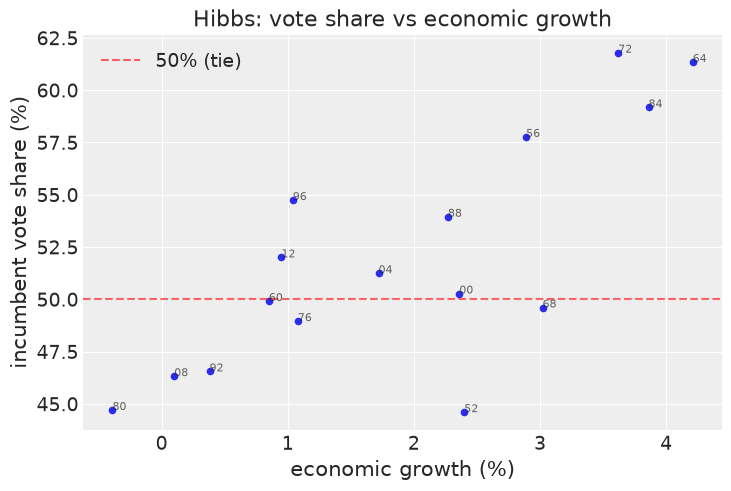

In [4]:
growth = df["growth"].values; vote = df["vote"].values
print(f"n elections = {len(growth)}")
print(f"growth range [{growth.min():.1f}, {growth.max():.1f}] %  | vote range [{vote.min():.1f}, {vote.max():.1f}] %")
print(f"corr(growth, vote) = {np.corrcoef(growth, vote)[0,1]:+.2f}")
for _, r in df.iterrows():
    plt.annotate(str(int(r['year']))[2:], (r['growth'], r['vote']), fontsize=8, alpha=.7)
plt.scatter(growth, vote, s=20)
plt.axhline(50, color="r", ls="--", alpha=.6, label="50% (tie)")
plt.xlabel("economic growth (%)"); plt.ylabel("incumbent vote share (%)")
plt.title("Hibbs: vote share vs economic growth"); plt.legend(); plt.show()

## Stage 3 — Model specification
$$v_i \sim \mathrm{Normal}(\mu_i, \sigma), \quad \mu_i = a + b\,g_i,$$
$$a \sim \mathrm{Normal}(50, 20), \quad b \sim \mathrm{Normal}(0, 10), \quad \sigma \sim \mathrm{HalfNormal}(10).$$
`a ~ Normal(50, 20)` centres the intercept on a tied election; `b ~ Normal(0, 10)` is weakly-informative
(growth could plausibly move vote share by a few points either way); `σ ~ HalfNormal(10)` allows a few
points of unexplained election-to-election noise.

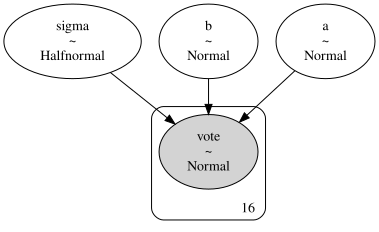

In [5]:
with pm.Model() as model:
    a = pm.Normal("a", 50, 20)
    b = pm.Normal("b", 0, 10)
    sigma = pm.HalfNormal("sigma", 10)
    mu = a + b*growth
    pm.Normal("vote", mu, sigma, observed=vote)
try:
    display(pm.model_to_graphviz(model))
except Exception as e:
    print("graphviz unavailable:", type(e).__name__, "| a,b,sigma -> vote")

## Stage 4 — Prior predictive on the VOTE scale
Draw (a, b, σ) from the prior and check the implied vote shares are mostly in a plausible electoral band
(roughly 30–70%), not piling up at impossible values.

Sampling: [a, b, sigma, vote]


prior predictive vote%: mean 51.3, sd 32.1, 5-95% [-2.2, 104.6]


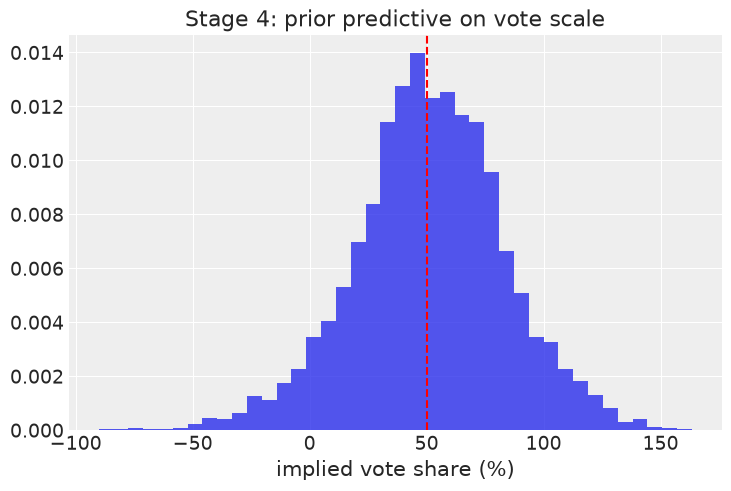

In [6]:
with model:
    pp = pm.sample_prior_predictive(samples=300, random_seed=RANDOM_SEED)
prior_v = pp.prior_predictive["vote"].values.reshape(-1)
print(f"prior predictive vote%: mean {prior_v.mean():.1f}, sd {prior_v.std():.1f}, "
      f"5-95% [{np.percentile(prior_v,5):.1f}, {np.percentile(prior_v,95):.1f}]")
plt.hist(prior_v, bins=40, density=True, alpha=.8)
plt.axvline(50, color="r", ls="--"); plt.xlabel("implied vote share (%)")
plt.title("Stage 4: prior predictive on vote scale"); plt.show()

## Stage 5 — Fit

In [7]:
t0 = time.time()
with model:
    idata = pm.sample(1000, tune=1000, chains=4, target_accept=0.9, random_seed=RANDOM_SEED,
                      progressbar=False, idata_kwargs={"log_likelihood": True})
    idata.extend(pm.sample_posterior_predictive(idata, random_seed=RANDOM_SEED, progressbar=False))
print(f"wall-clock {time.time()-t0:.1f}s")

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 2 jobs)


NUTS: [a, b, sigma]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 6 seconds.


Sampling: [vote]


wall-clock 7.3s


## Stage 6 — Diagnostics

         mean     sd  hdi_3%  hdi_97%  r_hat  ess_bulk  ess_tail
a      46.287  1.806  42.892   49.724    1.0    1646.0    1802.0
b       3.047  0.776   1.503    4.450    1.0    1596.0    1786.0
sigma   4.097  0.872   2.632    5.686    1.0    1616.0    1624.0

divergences: 0 | BFMI: [0.946 0.984 0.916 1.026]


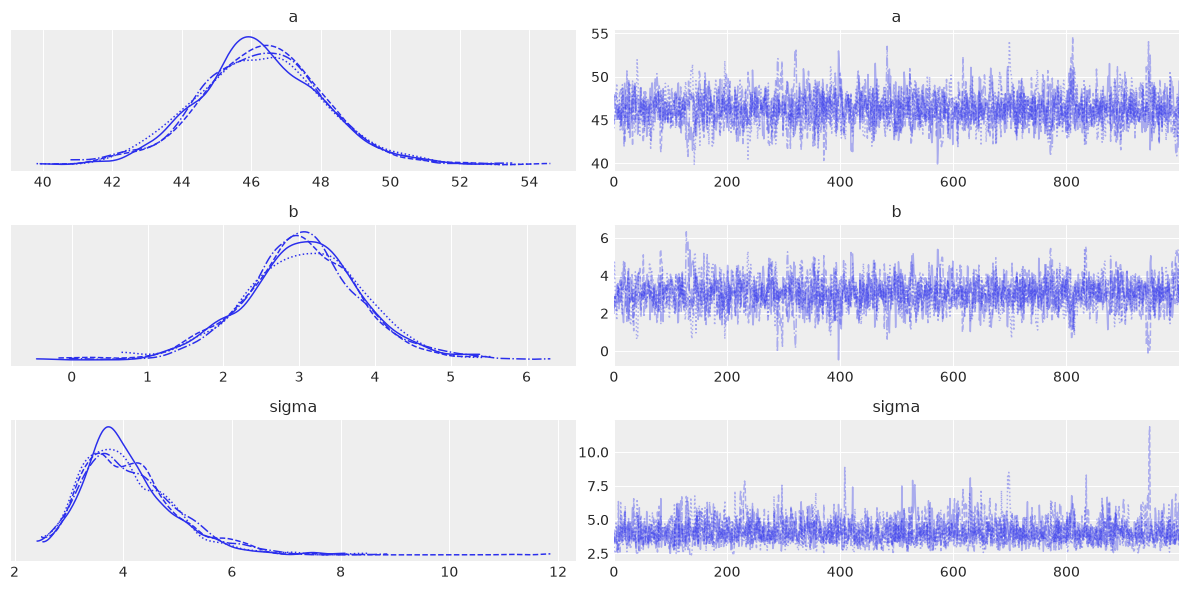

In [8]:
summ = az.summary(idata, var_names=["a","b","sigma"], hdi_prob=0.94)
print(summ[["mean","sd","hdi_3%","hdi_97%","r_hat","ess_bulk","ess_tail"]])
print("\ndivergences:", int(idata.sample_stats.diverging.values.sum()), "| BFMI:", np.round(az.bfmi(idata),3))
az.plot_trace(idata, var_names=["a","b","sigma"]); plt.tight_layout(); plt.show()

## Stage 7 — Interpretation (vote points per +1% growth)

Each +1% of economic growth -> +3.05 vote points (94% HDI 1.50, 4.45).
At zero growth the incumbent gets a = 46.3% (94% HDI 42.9, 49.7).
P(b > 0) = 0.999  (economy helps the incumbent)


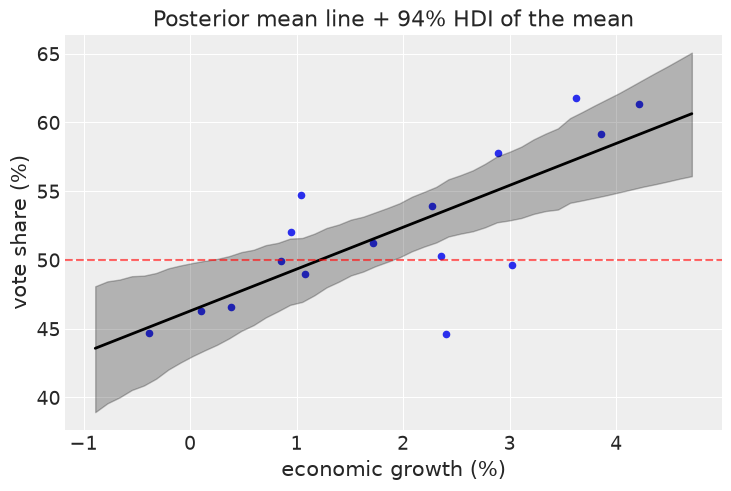

In [9]:
bm = idata.posterior["b"].mean().item(); am = idata.posterior["a"].mean().item()
b_hdi = az.hdi(idata, var_names=["b"], hdi_prob=0.94)["b"].values
a_hdi = az.hdi(idata, var_names=["a"], hdi_prob=0.94)["a"].values
p_pos = float((idata.posterior["b"].values > 0).mean())
print(f"Each +1% of economic growth -> +{bm:.2f} vote points (94% HDI {b_hdi[0]:.2f}, {b_hdi[1]:.2f}).")
print(f"At zero growth the incumbent gets a = {am:.1f}% (94% HDI {a_hdi[0]:.1f}, {a_hdi[1]:.1f}).")
print(f"P(b > 0) = {p_pos:.3f}  (economy helps the incumbent)")
gseq = np.linspace(growth.min()-0.5, growth.max()+0.5, 50)
post = az.extract(idata); ad = post["a"].values; bd = post["b"].values
mu_lines = ad[None,:] + bd[None,:]*gseq[:,None]
mu_mean = mu_lines.mean(1); mu_hdi = az.hdi(mu_lines.T, hdi_prob=0.94)
plt.scatter(growth, vote, s=20)
plt.plot(gseq, mu_mean, "k", lw=2); plt.fill_between(gseq, mu_hdi[:,0], mu_hdi[:,1], color="k", alpha=.25)
plt.axhline(50, color="r", ls="--", alpha=.6)
plt.xlabel("economic growth (%)"); plt.ylabel("vote share (%)")
plt.title("Posterior mean line + 94% HDI of the mean"); plt.show()

## Stage 8 — Posterior predictive check (continuous discrepancy stats)

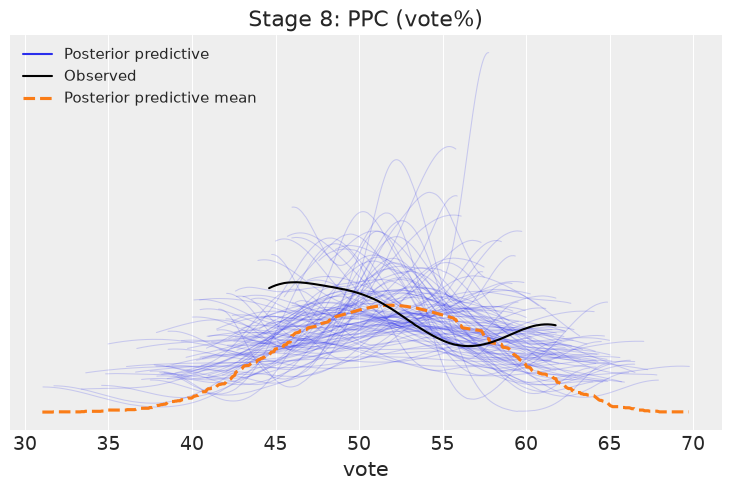

  mean: obs=  52.05  bayes-p=0.50
  sd  : obs=   5.43  bayes-p=0.56
  min : obs=  44.60  bayes-p=0.19
  max : obs=  61.79  bayes-p=0.54


In [10]:
az.plot_ppc(idata, num_pp_samples=100); plt.title("Stage 8: PPC (vote%)"); plt.show()
ppc = idata.posterior_predictive["vote"].values.reshape(-1, vote.size)
for name, fn in [("mean",np.mean),("sd",np.std),("min",np.min),("max",np.max)]:
    print(f"  {name:4s}: obs={fn(vote):7.2f}  bayes-p={(fn(ppc,axis=1)>=fn(vote)).mean():.2f}")

## Stage 9 — Comparison: `vote~growth` vs intercept-only (PSIS-LOO)
Does the economy actually predict the vote, or is a constant mean as good? With n = 16 the LOO estimate
is fragile, so we watch Pareto-k̂ closely.

In [11]:
with pm.Model() as model_null:
    a = pm.Normal("a", 50, 20); sigma = pm.HalfNormal("sigma", 10)
    pm.Normal("vote", a, sigma, observed=vote)
    idata_null = pm.sample(1000, tune=1000, chains=4, target_accept=0.9, random_seed=RANDOM_SEED,
                           progressbar=False, idata_kwargs={"log_likelihood": True})
cmp = az.compare({"growth": idata, "intercept_only": idata_null})
print(cmp[["rank","elpd_loo","elpd_diff","dse","weight"]])
S = idata.posterior.draw.size * idata.posterior.chain.size
thr = min(1 - 1/np.log10(S), 0.7)
maxk = max(az.loo(x, pointwise=True).pareto_k.values.max() for x in [idata, idata_null])
print(f"\nmax Pareto k-hat: {maxk:.2f} | threshold {thr:.2f}")
row2 = cmp.iloc[1]
print(f"elpd_diff of 2nd-ranked = {row2['elpd_diff']:.2f} +/- {row2['dse']:.2f} SE")

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 2 jobs)


NUTS: [a, sigma]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 4 seconds.


                rank   elpd_loo  elpd_diff       dse    weight
growth             0 -46.341052     0.0000  0.000000  0.887911
intercept_only     1 -51.684352     5.3433  3.630439  0.112089



max Pareto k-hat: 0.62 | threshold 0.70
elpd_diff of 2nd-ranked = 5.34 +/- 3.63 SE


## Stage 10 — Power-scaling prior sensitivity (slope b)

In [12]:
post = az.extract(idata); bd = post["b"].values; ad = post["a"].values; sd_ = post["sigma"].values
logprior = st.norm.logpdf(bd,0,10) + st.norm.logpdf(ad,50,20) + st.halfnorm.logpdf(sd_, scale=10)
print("alpha   E[b] (vote pts / %growth)")
for al in [0.8, 1.0, 1.25]:
    wgt = np.exp((al-1)*logprior); wgt /= wgt.sum()
    print(f" {al:4.2f}   {np.sum(wgt*bd):.3f}")

alpha   E[b] (vote pts / %growth)
 0.80   3.053
 1.00   3.047
 1.25   3.041


## Stage 11–12 — Predictive intervals for future elections, decision
We predict vote share at **growth = 2%** and **growth = 4%** with full **posterior predictive** intervals
(parameter uncertainty + residual σ), and a headline.

In [13]:
def predict_vote(g_new, idata):
    p = az.extract(idata); a = p["a"].values; b = p["b"].values; s = p["sigma"].values
    mu = a + b*g_new
    draws = rng.normal(mu, s)            # full predictive: adds residual noise
    return mu, draws
for g_new in [2.0, 4.0]:
    mu, draws = predict_vote(g_new, idata)
    mu_lo, mu_hi = np.percentile(mu, [5, 95])
    pr_lo, pr_hi = np.percentile(draws, [5, 95])
    p_win = float((draws > 50).mean())
    print(f"growth={g_new:.0f}%  mean vote {mu.mean():.1f}%  "
          f"(mean 90% [{mu_lo:.1f}, {mu_hi:.1f}]; predictive 90% [{pr_lo:.1f}, {pr_hi:.1f}])  "
          f"P(win)={p_win:.2f}")
os.makedirs("report", exist_ok=True); idata.to_netcdf("report/P05_idata.nc"); print("saved report/P05_idata.nc")

growth=2%  mean vote 52.4%  (mean 90% [50.7, 54.1]; predictive 90% [45.5, 59.4])  P(win)=0.74
growth=4%  mean vote 58.5%  (mean 90% [55.3, 61.6]; predictive 90% [51.0, 66.0])  P(win)=0.96


saved report/P05_idata.nc


## Stage 11–12 — Decision & communication

**Next model (Stage 11):** Hibbs's full "Bread and Peace" model adds a **cumulative military-fatalities**
term (the "peace" half). With only 16 elections, a hierarchical or robust-`StudentT` likelihood would
also guard against the occasional outlier election.

**Decision (Stage 12) — headline:** *the economy clearly helps the incumbent — each +1% of growth is worth
about **+3 percentage points** of vote share — but with only 16 elections the predictive interval for any
single future election spans roughly ±8 points, so growth tilts the odds without guaranteeing the outcome.*

## Exercises
1. Refit with a **StudentT** likelihood (heavy tails). Does any single election (e.g. 1952, 2008) change
   the slope much?
2. Reproduce the **mean** interval and the **predictive** interval at growth = 0%. Explain why the
   predictive one is much wider.
3. Hibbs's model has a second predictor (military fatalities). Sketch how you would add it and what the
   prior on its coefficient should be.